In [18]:
# Parquet dosyasından veriyi alıp pandas'a aktarma
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

table = pq.read_table('../data/nrel_data_2021_2023_Colorado.parquet')

df = table.to_pandas()

print(df)

                     Year  Month  Day  Hour  Minute  GHI  DHI  DNI  \
datetime                                                             
2021-01-01 00:00:00  2021      1    1     0       0    0    0    0   
2021-01-01 00:30:00  2021      1    1     0      30    0    0    0   
2021-01-01 01:00:00  2021      1    1     1       0    0    0    0   
2021-01-01 01:30:00  2021      1    1     1      30    0    0    0   
2021-01-01 02:00:00  2021      1    1     2       0    0    0    0   
...                   ...    ...  ...   ...     ...  ...  ...  ...   
2023-12-31 21:30:00  2023     12   31    21      30    0    0    0   
2023-12-31 22:00:00  2023     12   31    22       0    0    0    0   
2023-12-31 22:30:00  2023     12   31    22      30    0    0    0   
2023-12-31 23:00:00  2023     12   31    23       0    0    0    0   
2023-12-31 23:30:00  2023     12   31    23      30    0    0    0   

                     Wind Speed  Temperature  Cloud Type  Dew Point  \
datetime          

In [19]:
# Gece Körlüğü Filtrelemesi
# Geceleri güneş paneli üretim yapmayacağı için (GHI = 0) bunları modelde tutmak başarı oranının (RMSE) "sahte" şekilde 
# yüksek çıkmasına neden olur.
night_mask = (df['Solar Zenith Angle'] > 90) | (df['GHI'] == 0)
day_df = df.loc[~night_mask].reset_index(drop=True)
print(day_df.head())
print(f"Eski satır: {len(df)}, Gündüz satır: {len(day_df)}")

   Year  Month  Day  Hour  Minute  GHI  DHI  DNI  Wind Speed  Temperature  \
0  2021      1    1     7      30    9    9    1         1.6         -5.0   
1  2021      1    1     8       0   70   41  310         1.8         -3.8   
2  2021      1    1     8      30  105   75  177         2.0         -2.7   
3  2021      1    1     9       0  140  129   45         2.2         -1.6   
4  2021      1    1     9      30  184  179   15         2.0         -0.7   

   Cloud Type  Dew Point  Relative Humidity  Solar Zenith Angle  \
0           8       -8.7          75.529999           89.129997   
1           0       -7.9          73.199997           84.540001   
2           4       -7.9          67.440002           80.080002   
3           4       -6.8          67.480003           75.949997   
4           4       -6.8          63.180000           72.239998   

   Requested Year  
0            2021  
1            2021  
2            2021  
3            2021  
4            2021  
Eski satır: 52

In [20]:
# Günlük Gürültü Skorunu Bulma (Daily Volatility)
# Her günü GHI bazında ortalama ve standart sapmasını bulan tablo oluşturma
day_df['datetime'] = pd.to_datetime(
    day_df[['Year','Month','Day','Hour','Minute']].rename(columns={'Year':'year',
                                                                  'Month':'month',
                                                                  'Day':'day',
                                                                  'Hour': 'hour',
                                                                  'Minute':'minute'}))

day_df = day_df.set_index('datetime')

daily_table = day_df.resample('D')['GHI'].agg(['mean', 'std'])
print(daily_table)

                  mean         std
datetime                          
2021-01-01  271.526316  169.584908
2021-01-02  304.842105  191.342991
2021-01-03  226.578947  190.342474
2021-01-04  308.157895  178.394775
2021-01-05  260.157895  145.933494
...                ...         ...
2023-12-27  278.736842  175.354511
2023-12-28  302.842105  169.192613
2023-12-29  303.210526  168.930485
2023-12-30  299.947368  167.132174
2023-12-31  218.947368  122.848359

[1095 rows x 2 columns]


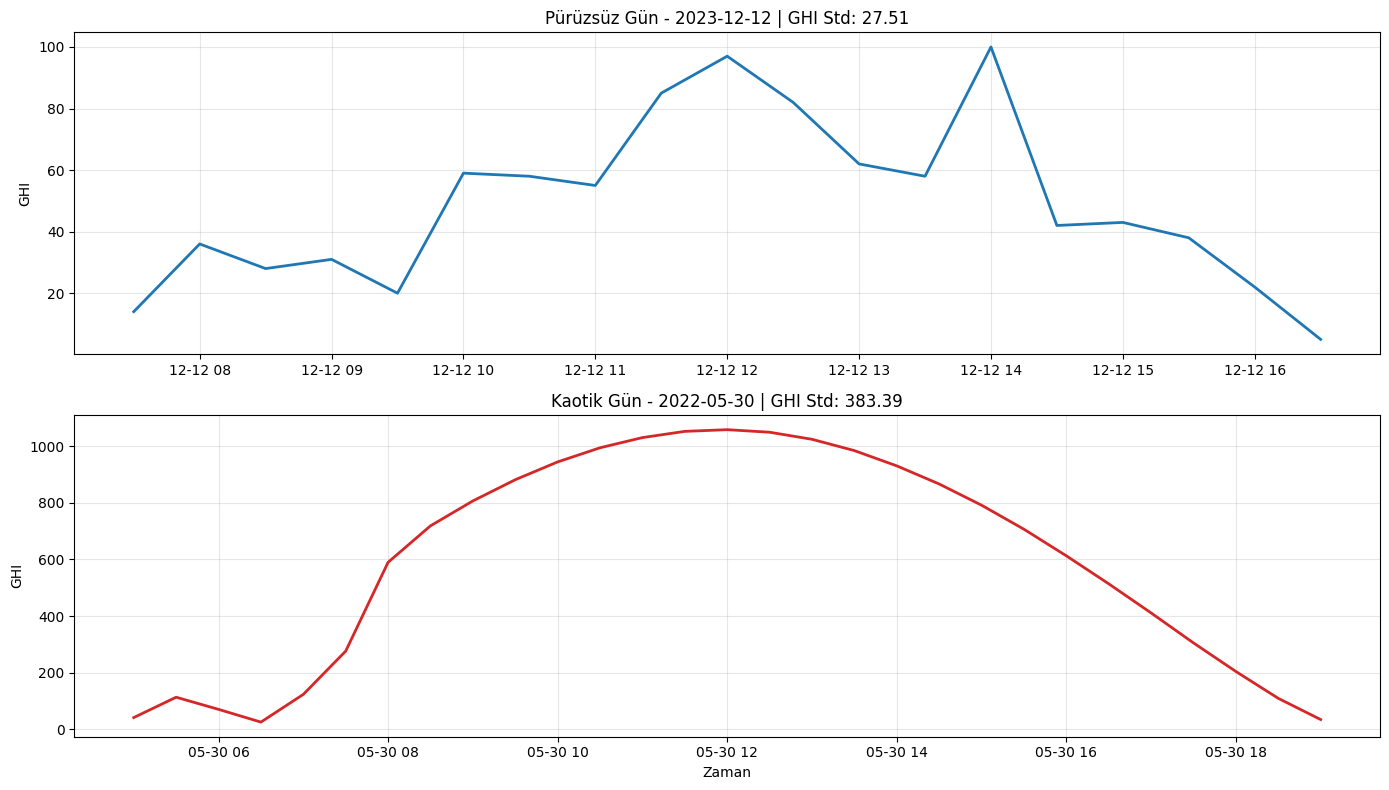

In [21]:
# En düşük çıkan yaz günü ile en yüksek çıkan bahar günün GHI karşılaştırması
import matplotlib.pyplot as plt

smooth_day = daily_table['std'].idxmin()
chaotic_day = daily_table['std'].idxmax()

smooth_ghi = day_df.loc[str(smooth_day.date())]['GHI']
chaotic_ghi = day_df.loc[str(chaotic_day.date())]['GHI']

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(smooth_ghi.index, smooth_ghi.values, color='tab:blue', linewidth=2)
axes[0].set_title(f"Pürüzsüz Gün - {smooth_day.date()} | GHI Std: {daily_table.loc[smooth_day, 'std']:.2f}")
axes[0].set_ylabel("GHI")
axes[0].grid(True, alpha=0.3)

axes[1].plot(chaotic_ghi.index, chaotic_ghi.values, color='tab:red', linewidth=2)
axes[1].set_title(f"Kaotik Gün - {chaotic_day.date()} | GHI Std: {daily_table.loc[chaotic_day, 'std']:.2f}")
axes[1].set_xlabel("Zaman")
axes[1].set_ylabel("GHI")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/smooth_chaotic_ghi.pdf')
plt.show()

       mean_scaled    std_scaled
mean -9.084565e-17  1.752023e-16
std   1.000457e+00  1.000457e+00

Kume ozetleri (ortalama degerler):
               mean         std
Cluster                        
0        167.420222  111.571580
1        346.624687  214.832097
2        515.769556  308.895243

Kume etiket dagilimi:
Cluster_Label
Kaotik     460
Gunesli    448
Kapali     187
Name: count, dtype: int64


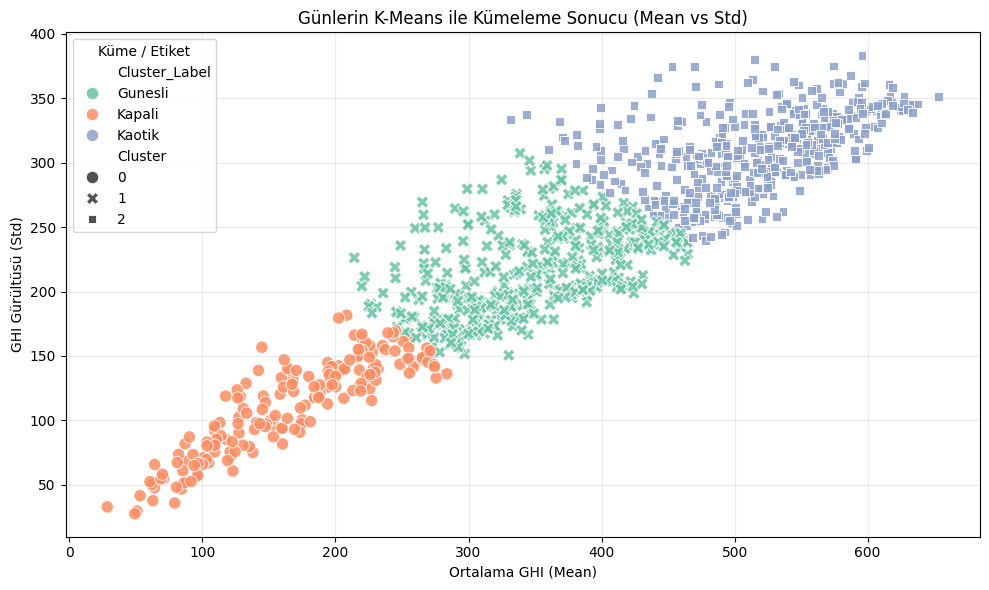

In [22]:
# Gorev 4: Feature Scaling (mean ve std'yi ayni olcege getir)
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

features = daily_table[['mean', 'std']].dropna().copy()
scaled_features = scaler.fit_transform(features)

# Kontrol: olceklenmis degerlerin ortalamasi ~0 ve std'si ~1 olmalidir
scaled_df = pd.DataFrame(scaled_features, index=features.index, columns=['mean_scaled', 'std_scaled'])
print(scaled_df.describe().loc[['mean', 'std']])

# Gorev 5: K-Means ile 3 kumeye ayirma
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_ids = kmeans.fit_predict(scaled_features)

clustered_daily = features.copy()
clustered_daily['Cluster'] = cluster_ids

# Kume ozetleri: hangi kume hangi gun tipine daha yakin?
cluster_summary = clustered_daily.groupby('Cluster')[['mean', 'std']].mean().sort_values('mean')
print('\nKume ozetleri (ortalama degerler):')
print(cluster_summary)

# Kumeleri yorumlamak icin basit isimlendirme (dusuk mean=Kapali, yuksek std=Kaotik, kalan=Gunesli)
label_map = {}
closed_cluster = cluster_summary.index[0]
chaotic_cluster = cluster_summary['std'].idxmax()
label_map[closed_cluster] = 'Kapali'
label_map[chaotic_cluster] = 'Kaotik'
for c in cluster_summary.index:
    if c not in label_map:
        label_map[c] = 'Gunesli'

clustered_daily['Cluster_Label'] = clustered_daily['Cluster'].map(label_map)
print('\nKume etiket dagilimi:')
print(clustered_daily['Cluster_Label'].value_counts())

# Gorev 6: Scatter Plot Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=clustered_daily,
    x='mean',
    y='std',
    hue='Cluster_Label',
    style='Cluster',
    palette='Set2',
    s=80, 
    alpha=0.85
)
plt.title('Günlerin K-Means ile Kümeleme Sonucu (Mean vs Std)')
plt.xlabel('Ortalama GHI (Mean)')
plt.ylabel('GHI Gürültüsü (Std)')
plt.grid(alpha=0.25)
plt.legend(title='Küme / Etiket')
plt.tight_layout()
plt.savefig('../outputs/plots/k-means-daily.pdf')
plt.show()

# Gerekirse daha sonra kullanmak icin tabloyu kaydet
clustered_daily.to_csv('../outputs/reports/daily_clusters.csv', index=True)


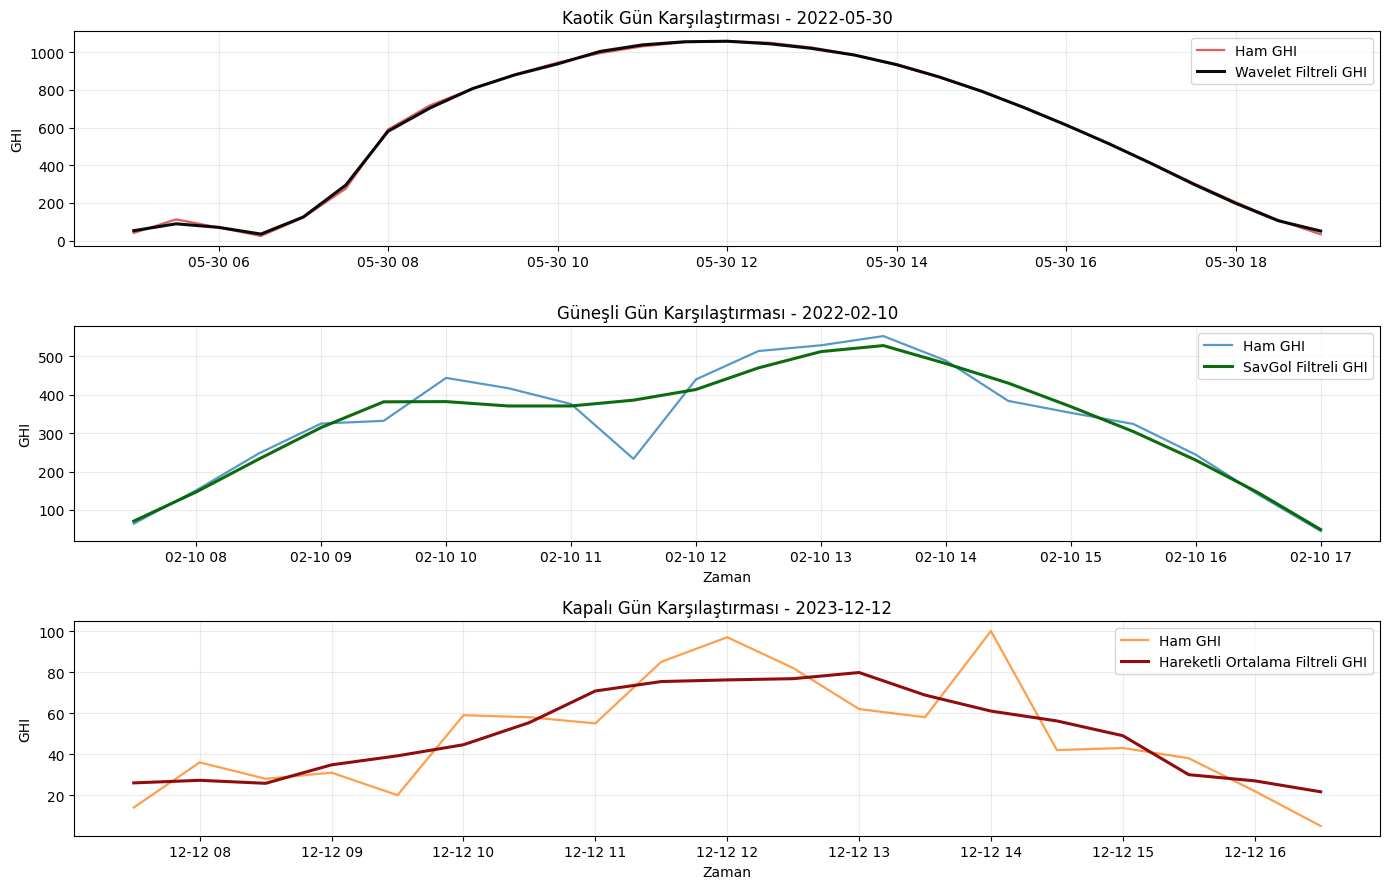

Filtreleme tamamlandi. Kayitlar:
- ../outputs/plots/filter_before_after_comparison.pdf
- ../outputs/reports/day_rows_with_filtered_ghi.csv


In [23]:
import os
import sys

# Proje kök dizinini Python arama yolunda en üste al
project_root = os.path.abspath(os.path.join('..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root) # Proje kök dizinini arama yolunun en üstüne ekleyelim

else:
    sys.path.remove(project_root) # Eğer zaten varsa, önce kaldırıp sonra tekrar ekleyelim ki güncel versiyonun yüklendiğinden emin olalım
    sys.path.insert(0, project_root)


from src.filters import apply_filter_by_label
import numpy as np
import matplotlib.pyplot as plt
import os

# 1) Gunluk Cluster_Label bilgisini 30 dakikalik ham tabloya tarih bazinda map et
# day_df su an datetime index'li; once satir bazli tabloya ceviriyoruz.
day_rows = day_df.reset_index().copy()
day_rows['date'] = day_rows['datetime'].dt.date

# clustered_daily index'i gunluk tarih (Timestamp). Bunu date tipine cevirip map yapacagiz.
label_by_date = clustered_daily['Cluster_Label'].copy()
label_by_date.index = pd.to_datetime(label_by_date.index).date

day_rows['Cluster_Label'] = day_rows['date'].map(label_by_date)

# 2) Etikete gore adaptif filtreyi uygulayip yeni GHI_Filtered kolonu uret
day_rows['GHI_Filtered'] = np.nan

for current_date, grp in day_rows.groupby('date', sort=True):
    label = grp['Cluster_Label'].iloc[0]
    if pd.isna(label):
        continue

    filtered_signal = apply_filter_by_label(
        signal=grp['GHI'].values,
        label=label,
        savgol_window=9,
        savgol_polyorder=3,
        wavelet_name='db4',
        wavelet_level=2,
        wavelet_threshold_scale=0.8,
        moving_window=5,
    )

    day_rows.loc[grp.index, 'GHI_Filtered'] = filtered_signal

# 3) Karsilastirma icin temsil gunleri sec
# Kaotik icin std en yuksek; Gunesli icin std en dusuk gunu seciyoruz.
chaotic_candidates = clustered_daily[clustered_daily['Cluster_Label'] == 'Kaotik']
sunny_candidates = clustered_daily[clustered_daily['Cluster_Label'] == 'Gunesli']
closed_candidates = clustered_daily[clustered_daily['Cluster_Label'] == 'Kapali']

if chaotic_candidates.empty or sunny_candidates.empty:
    raise ValueError("Kaotik veya Gunesli etiketli gun bulunamadi. Kumeleme etiketlerini kontrol et.")

chaotic_date = chaotic_candidates['std'].idxmax().date()
sunny_date = sunny_candidates['std'].idxmin().date()
closed_date = closed_candidates['std'].idxmin().date()

chaotic_rows = day_rows[day_rows['date'] == chaotic_date]
sunny_rows = day_rows[day_rows['date'] == sunny_date]
closed_rows = day_rows[day_rows['date'] == closed_date]

# 4) Ustte Kaotik (Wavelet), ortada Gunesli (SavGol) ve altta Kapali (Hareketli Ortalama) olacak sekilde once/sonra ciz
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=False)

axes[0].plot(
    chaotic_rows['datetime'],
    chaotic_rows['GHI'],
    color='tab:red',
    linewidth=1.6,
    alpha=0.75,
    label='Ham GHI',
)
axes[0].plot(
    chaotic_rows['datetime'],
    chaotic_rows['GHI_Filtered'],
    color='black',
    linewidth=2.2,
    alpha=0.95,
    label='Wavelet Filtreli GHI',
)
axes[0].set_title(f"Kaotik Gün Karşılaştırması - {chaotic_date}")
axes[0].set_ylabel('GHI')
axes[0].grid(True, alpha=0.25)
axes[0].legend()

axes[1].plot(
    sunny_rows['datetime'],
    sunny_rows['GHI'],
    color='tab:blue',
    linewidth=1.6,
    alpha=0.75,
    label='Ham GHI',
)
axes[1].plot(
    sunny_rows['datetime'],
    sunny_rows['GHI_Filtered'],
    color='darkgreen',
    linewidth=2.2,
    alpha=0.95,
    label='SavGol Filtreli GHI',
)
axes[1].set_title(f"Güneşli Gün Karşılaştırması - {sunny_date}")
axes[1].set_xlabel('Zaman')
axes[1].set_ylabel('GHI')
axes[1].grid(True, alpha=0.25)
axes[1].legend()

axes[2].plot(
    closed_rows['datetime'],
    closed_rows['GHI'],
    color='tab:orange',
    linewidth=1.6,
    alpha=0.75,
    label='Ham GHI',
)
axes[2].plot(
    closed_rows['datetime'],
    closed_rows['GHI_Filtered'],
    color='darkred',
    linewidth=2.2,
    alpha=0.95,
    label='Hareketli Ortalama Filtreli GHI',
)
axes[2].set_title(f"Kapalı Gün Karşılaştırması - {closed_date}")
axes[2].set_xlabel('Zaman')
axes[2].set_ylabel('GHI')
axes[2].grid(True, alpha=0.25)
axes[2].legend()

plt.tight_layout()
os.makedirs('../outputs/plots', exist_ok=True)
plt.savefig('../outputs/plots/filter_before_after_comparison.pdf')
plt.show()

# Istersen sonraki asamalar icin filtrelenmis satir bazli tabloyu da kaydet
os.makedirs('../outputs/reports', exist_ok=True)
day_rows.to_csv('../outputs/reports/day_rows_with_filtered_ghi.csv', index=False)

print("Filtreleme tamamlandi. Kayitlar:")
print("- ../outputs/plots/filter_before_after_comparison.pdf")
print("- ../outputs/reports/day_rows_with_filtered_ghi.csv")